# Deterministic Dataset Inspection — `mass_action_3s_det`

This notebook inspects datasets generated with `--deterministic` (forward Euler ODE).
Key differences from the stochastic datasets:
- Each item has **M=1** trajectory (no SSA ensemble)
- Trajectories are smooth continuous curves, not noisy jump processes
- Values are floating-point counts, not integers

Sections:
1. Load dataset
2. Basic stats and shape checks
3. Sample trajectory plots
4. Dynamical regime classification
5. Value range analysis
6. CRN topology statistics

In [15]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# Make sure src/ and repo root are importable
REPO_ROOT = Path("../..").resolve()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

# ── Loading config ────────────────────────────────────────────────────────────
# Set LOAD_FROM_WANDB=True to pull the artifact, or point LOCAL_* at local files.
LOAD_FROM_WANDB = True
ARTIFACT_REF = "mass_action_3s_det_dataset:latest"
LOCAL_TRAIN = REPO_ROOT / "experiments/datasets/mass_action_3s_det_train.pt"
LOCAL_VAL = REPO_ROOT / "experiments/datasets/mass_action_3s_det_val.pt"

if LOAD_FROM_WANDB:
    import wandb

    api = wandb.Api()
    artifact = api.artifact(f"jan-mikelson-independent/crn-surrogate/{ARTIFACT_REF}")
    artifact_dir = artifact.download()
    train_files = sorted(Path(artifact_dir).glob("*_train.pt"))
    val_files = sorted(Path(artifact_dir).glob("*_val.pt"))
    train_dataset = torch.load(train_files[0], weights_only=False)
    val_dataset = torch.load(val_files[0], weights_only=False)
else:
    train_dataset = torch.load(LOCAL_TRAIN, weights_only=False)
    val_dataset = torch.load(LOCAL_VAL, weights_only=False)

print(f"Train: {len(train_dataset):,} items")
print(f"Val:   {len(val_dataset):,} items")

wandb: Downloading large artifact 'mass_action_3s_det_dataset:latest', 59.24MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:07.2 (8.3MB/s)


Train: 30,000 items
Val:   3,000 items


## Basic stats and shape checks

In [16]:
item = train_dataset[0]
traj = item.trajectories  # should be (1, T, n_species)
print("trajectories shape :", traj.shape)
print("  M (should be 1)  :", traj.shape[0])
print("  T (time points)  :", traj.shape[1])
print("  n_species        :", traj.shape[2])
print("times shape        :", item.times.shape)
print("initial_state      :", item.initial_state)
print("motif_label        :", item.motif_label)
print("\nFirst few time points:", item.times[:5].numpy())
print("Last few time points :", item.times[-5:].numpy())

# Confirm M=1 across the whole dataset
m_values = {
    train_dataset[i].trajectories.shape[0] for i in range(min(200, len(train_dataset)))
}
print(f"\nDistinct M values in first 200 items: {m_values}  (should be {{1}})")

# Check for NaN / Inf
n_nan = sum(
    1
    for i in range(len(train_dataset))
    if torch.isnan(train_dataset[i].trajectories).any()
    or torch.isinf(train_dataset[i].trajectories).any()
)
print(f"Items with NaN/Inf: {n_nan} / {len(train_dataset)}")

trajectories shape : torch.Size([1, 100, 3])
  M (should be 1)  : 1
  T (time points)  : 100
  n_species        : 3
times shape        : torch.Size([100])
initial_state      : tensor([ 0., 10., 11.])
motif_label        : mass_action

First few time points: [0.        0.2020202 0.4040404 0.6060606 0.8080808]
Last few time points : [19.19192  19.39394  19.595959 19.79798  20.      ]

Distinct M values in first 200 items: {1}  (should be {1})
Items with NaN/Inf: 0 / 30000


## Sample trajectory plots

Because M=1 there is no ensemble spread — we plot the single ODE trajectory directly.

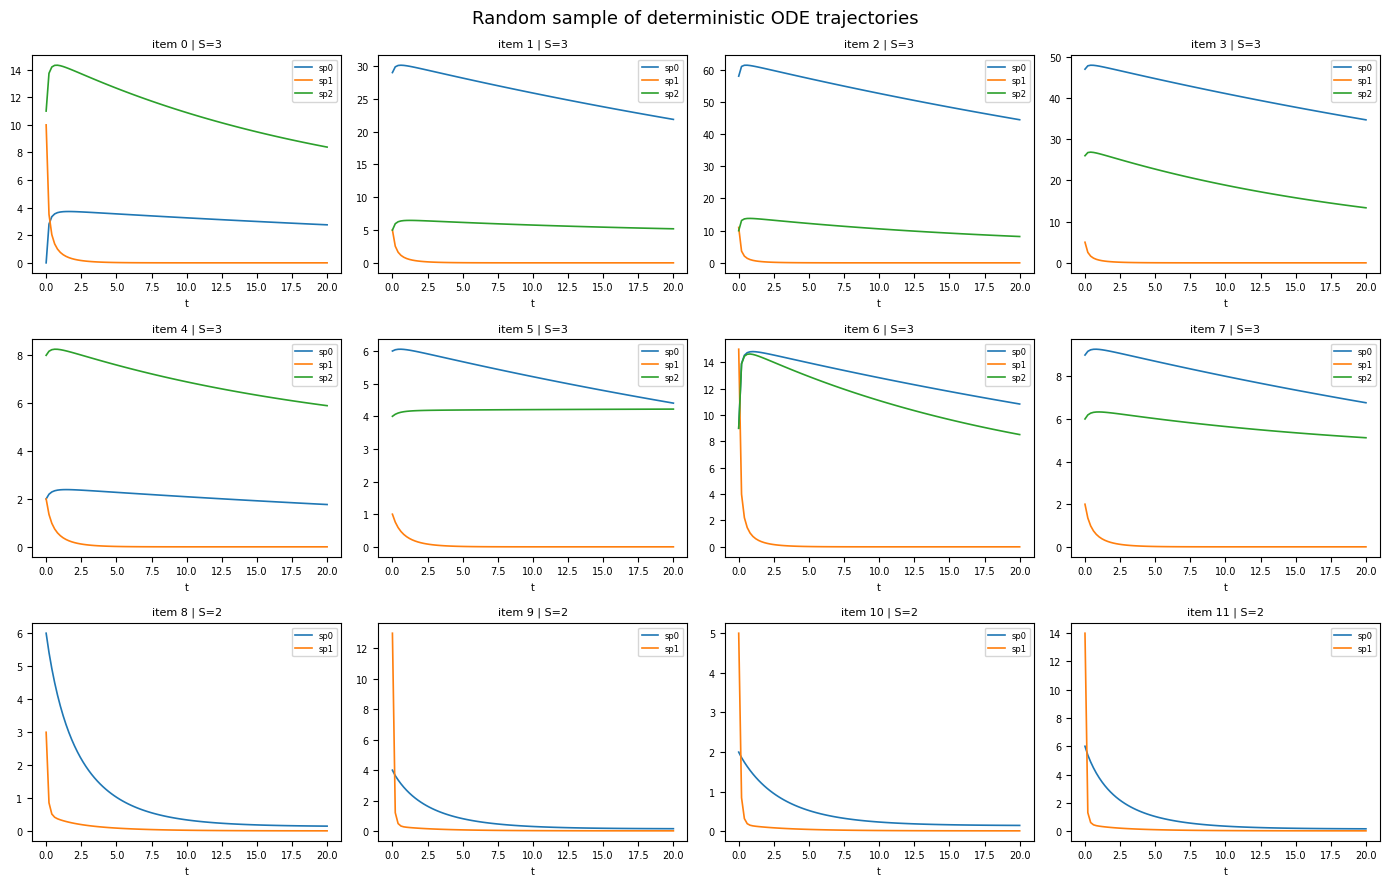

In [18]:
N_EXAMPLES = 12
np.random.seed(0)
indices = np.random.choice(len(train_dataset), size=N_EXAMPLES, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle("Random sample of deterministic ODE trajectories", fontsize=13)

for ax, idx in zip(axes.flat, indices):
    item = train_dataset[int(idx)]
    traj = item.trajectories[0].numpy()  # (T, n_species) — drop M dim
    t = item.times.numpy()
    n_s = traj.shape[1]
    colors = plt.cm.tab10.colors
    for s in range(n_s):
        ax.plot(t, traj[:, s], color=colors[s % 10], lw=1.2, label=f"sp{s}")
    ax.set_title(f"item {idx} | S={n_s}", fontsize=8)
    ax.set_xlabel("t", fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## Smoothness check

ODE trajectories should be smooth. We measure the mean absolute second derivative (discretised) per trajectory as a proxy for smoothness. Spiky values would indicate numerical issues.

=== Trajectory roughness (relative 2nd difference) ===
   50th percentile: 0.01068
   75th percentile: 0.04170
   90th percentile: 0.15987
   95th percentile: 0.31154
   99th percentile: 0.70630
  max:              1.38105
  Items with roughness > 0.01: 15359


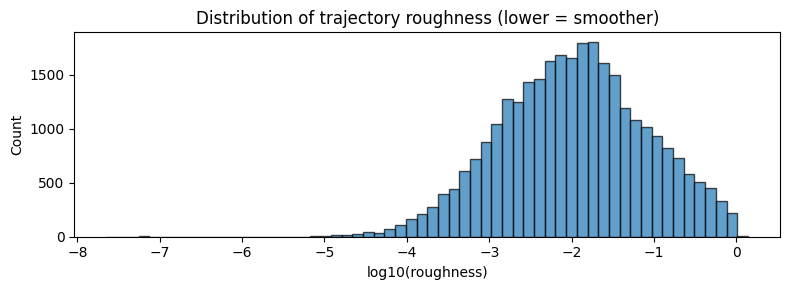

In [19]:
def trajectory_roughness(item) -> float:
    """Mean absolute second difference across all species."""
    traj = item.trajectories[0].numpy()  # (T, S)
    d2 = np.diff(traj, n=2, axis=0)  # (T-2, S)
    scale = np.abs(traj).mean() + 1e-6
    return float(np.abs(d2).mean() / scale)


roughness = np.array(
    [trajectory_roughness(train_dataset[i]) for i in range(len(train_dataset))]
)

print("=== Trajectory roughness (relative 2nd difference) ===")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p:3d}th percentile: {np.percentile(roughness, p):.5f}")
print(f"  max:              {roughness.max():.5f}")
print(f"  Items with roughness > 0.01: {(roughness > 0.01).sum()}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(np.log10(roughness + 1e-9), bins=60, edgecolor="black", alpha=0.7)
ax.set_xlabel("log10(roughness)")
ax.set_ylabel("Count")
ax.set_title("Distribution of trajectory roughness (lower = smoother)")
plt.tight_layout()
plt.show()

## Dynamical regime classification

In [20]:
def classify_species_dynamics(traj_species: np.ndarray) -> str:
    """Classify a single species trajectory into a dynamical regime."""
    T = len(traj_species)
    half = T // 2
    y = traj_species

    start_val = np.mean(y[:3])
    end_val = np.mean(y[-3:])
    peak_val = np.max(y)
    trough_val = np.min(y)
    scale = max(np.mean(np.abs(y)), 1e-6)

    if scale < 0.5:
        return "near_zero"

    dy = np.diff(y)
    sign_changes = np.sum(np.abs(np.diff(np.sign(dy))) > 0)
    overall_range = peak_val - trough_val
    rel_change = (end_val - start_val) / scale
    late_cv = np.std(y[half:]) / (np.mean(np.abs(y[half:])) + 1e-6)

    if peak_val > 1e4:
        return "blowup"

    if sign_changes > T * 0.3 and overall_range / scale > 0.3:
        late_range = np.max(y[half:]) - np.min(y[half:])
        late_mean = np.mean(np.abs(y[half:]))
        if late_range > 0.3 * late_mean and late_mean > 1.0:
            return "oscillatory"

    peak_idx = np.argmax(y)
    if peak_idx < T * 0.4 and peak_val > start_val * 1.5 and end_val < peak_val * 0.5:
        return "transient_peak"

    if rel_change > 0.3 and end_val > start_val:
        return "growth"

    if abs(rel_change) < 0.15 and late_cv < 0.15:
        return "steady_state"

    if rel_change < -0.3 and end_val > 0.5:
        return "decay_to_nonzero"

    if rel_change < -0.3 and end_val < 0.5:
        return "decay_to_zero"

    return "slow_dynamics"


REGIME_PRIORITY = [
    "blowup",
    "oscillatory",
    "transient_peak",
    "growth",
    "steady_state",
    "decay_to_nonzero",
    "slow_dynamics",
    "decay_to_zero",
    "near_zero",
]


def classify_item(item):
    """Return (species_labels, item_label, stats) for one TrajectoryItem."""
    traj = item.trajectories[0].numpy()  # (T, S) — M=1, drop M dim
    T, S = traj.shape

    species_labels = [classify_species_dynamics(traj[:, s]) for s in range(S)]

    item_label = "near_zero"
    for p in REGIME_PRIORITY:
        if p in species_labels:
            item_label = p
            break

    stats = {
        "n_species": S,
        "n_active_species": sum(1 for l in species_labels if l != "near_zero"),
        "max_val": float(np.max(np.abs(traj))),
        "species_labels": species_labels,
    }
    return species_labels, item_label, stats


print("Classifying training items...")
train_cls = [classify_item(train_dataset[i]) for i in range(len(train_dataset))]
train_labels = [c[1] for c in train_cls]

print("Classifying validation items...")
val_cls = [classify_item(val_dataset[i]) for i in range(len(val_dataset))]
val_labels = [c[1] for c in val_cls]

print("\n=== Training regime distribution ===")
for label, cnt in sorted(Counter(train_labels).items(), key=lambda x: -x[1]):
    print(f"  {label:<20s}: {cnt:6d}  ({100 * cnt / len(train_labels):5.1f}%)")

print("\n=== Validation regime distribution ===")
for label, cnt in sorted(Counter(val_labels).items(), key=lambda x: -x[1]):
    print(f"  {label:<20s}: {cnt:6d}  ({100 * cnt / len(val_labels):5.1f}%)")

Classifying training items...
Classifying validation items...

=== Training regime distribution ===
  transient_peak      :  10103  ( 33.7%)
  growth              :   7056  ( 23.5%)
  decay_to_nonzero    :   6427  ( 21.4%)
  steady_state        :   2189  (  7.3%)
  decay_to_zero       :   1796  (  6.0%)
  near_zero           :   1239  (  4.1%)
  slow_dynamics       :    991  (  3.3%)
  blowup              :    189  (  0.6%)
  oscillatory         :     10  (  0.0%)

=== Validation regime distribution ===
  transient_peak      :    974  ( 32.5%)
  growth              :    694  ( 23.1%)
  decay_to_nonzero    :    679  ( 22.6%)
  steady_state        :    214  (  7.1%)
  decay_to_zero       :    198  (  6.6%)
  slow_dynamics       :    109  (  3.6%)
  near_zero           :    107  (  3.6%)
  blowup              :     25  (  0.8%)


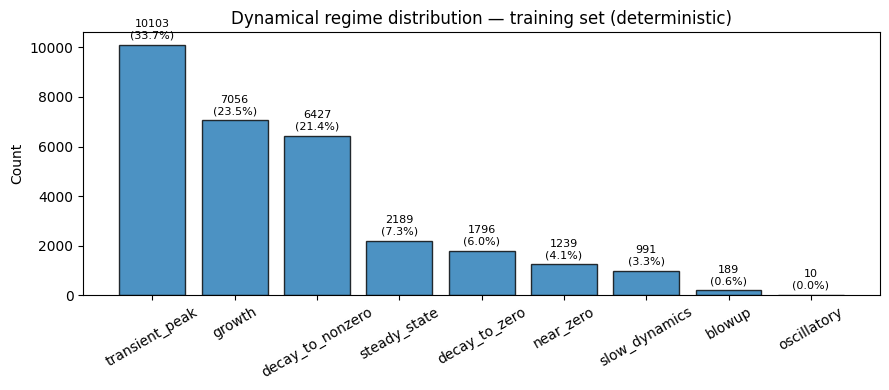

In [21]:
# Bar chart of regime distribution
label_counts = Counter(train_labels)
regimes = sorted(label_counts, key=lambda r: -label_counts[r])
counts = [label_counts[r] for r in regimes]
total = sum(counts)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(regimes, counts, edgecolor="black", alpha=0.8)
ax.bar_label(
    bars,
    labels=[f"{c}\n({100 * c / total:.1f}%)" for c in counts],
    fontsize=8,
    padding=3,
)
ax.set_ylabel("Count")
ax.set_title("Dynamical regime distribution — training set (deterministic)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

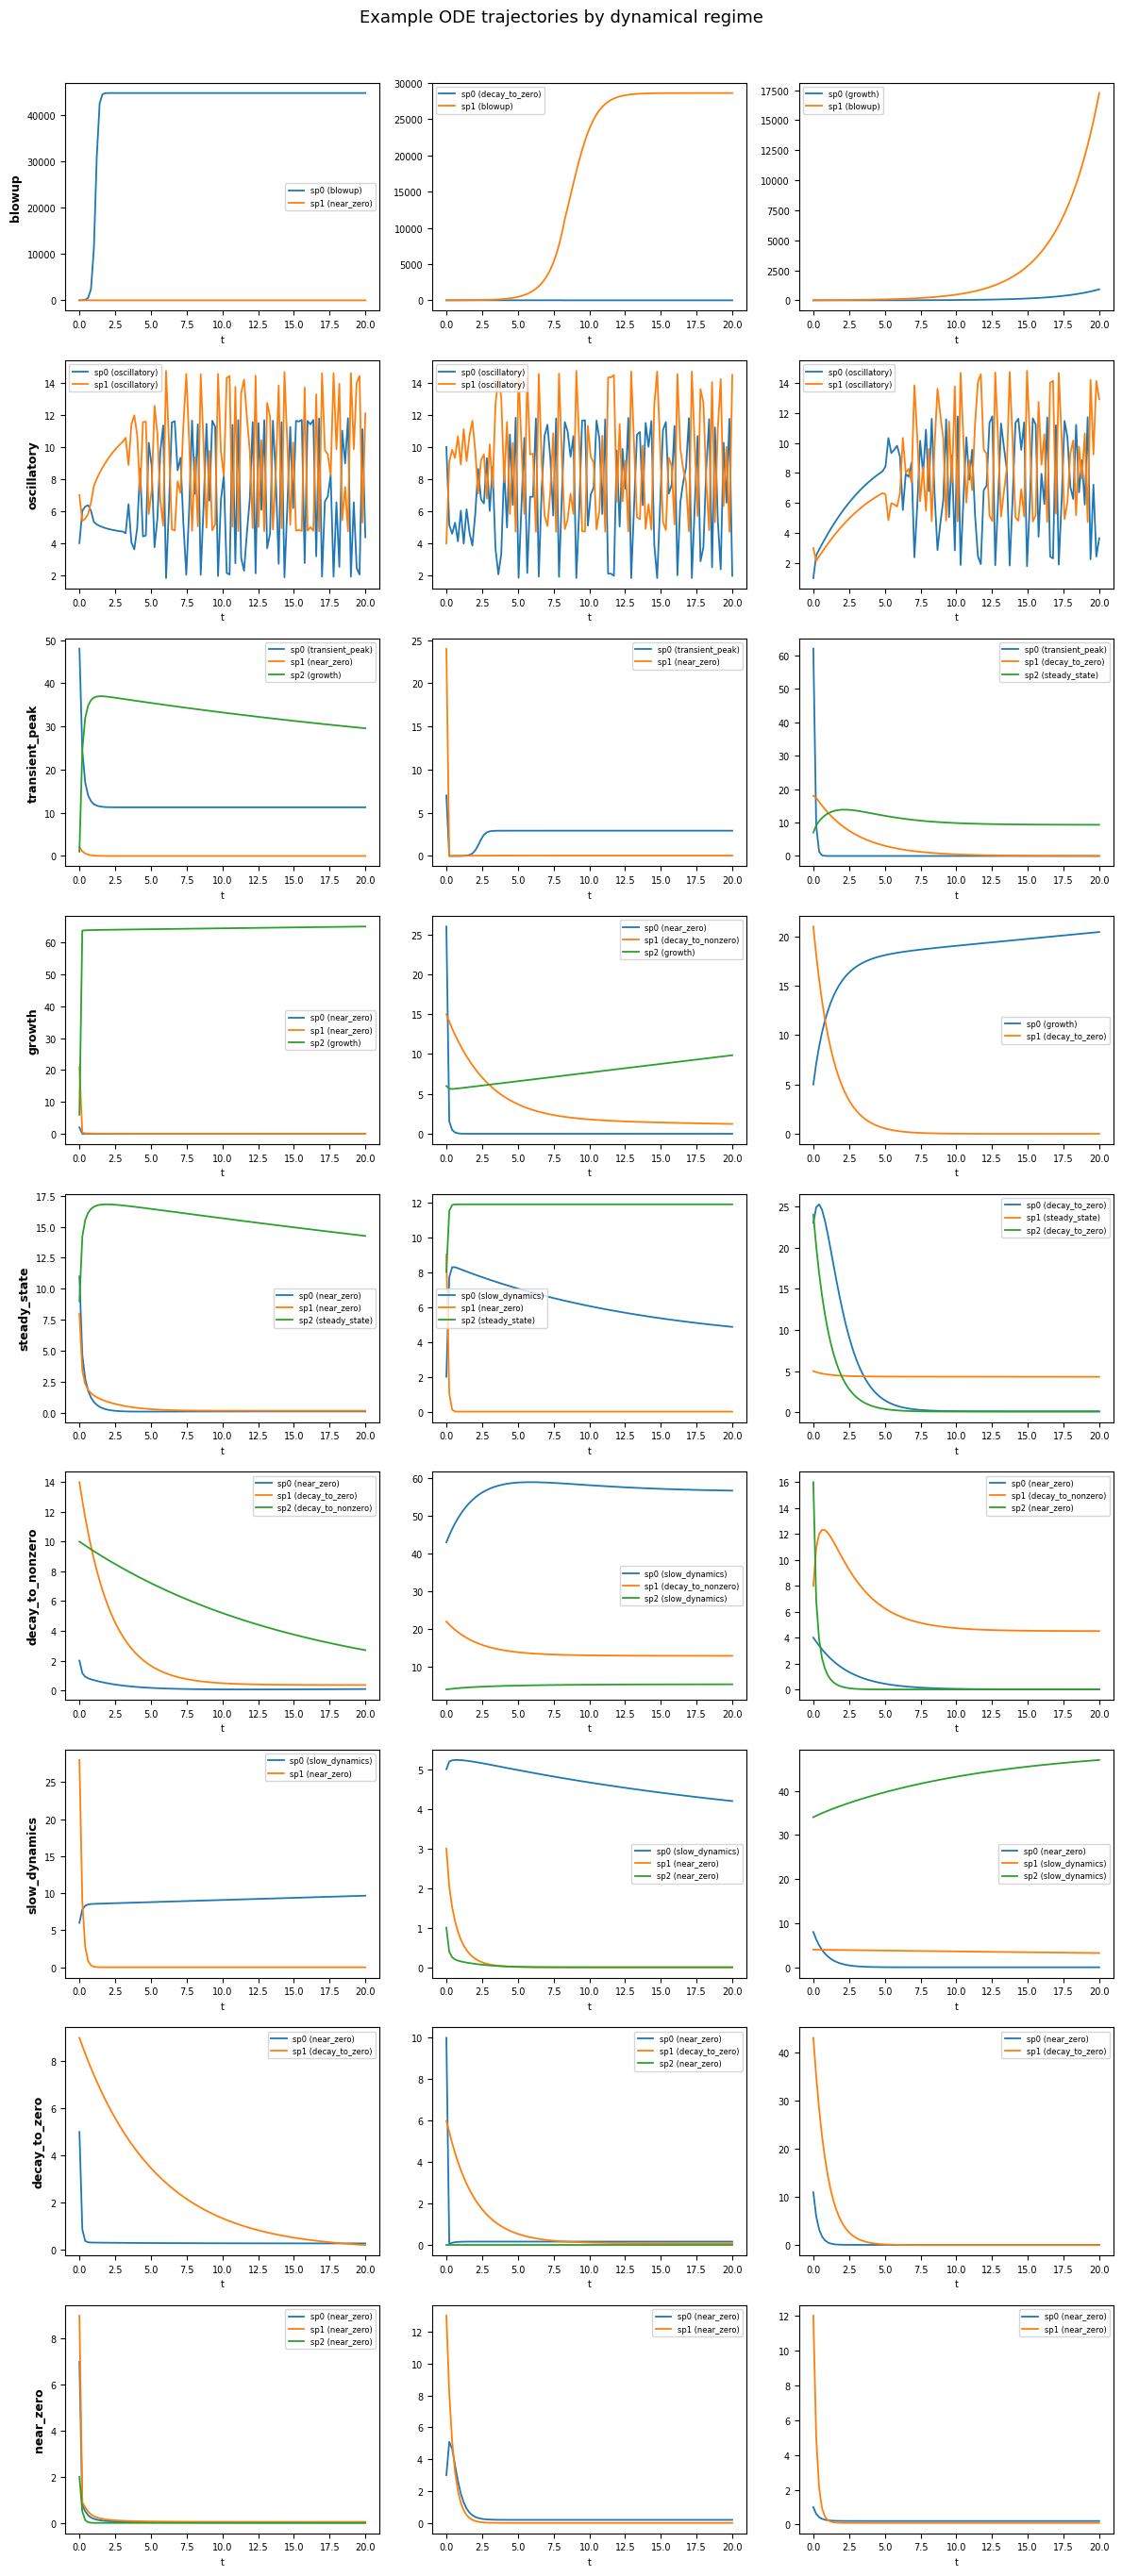

In [22]:
# Plot example trajectories per regime
def plot_regime_examples(dataset, classifications, n_examples=3, seed=42):
    labels = [c[1] for c in classifications]
    unique_labels = [r for r in REGIME_PRIORITY if r in labels]

    fig, axes = plt.subplots(
        len(unique_labels),
        n_examples,
        figsize=(4 * n_examples, 3 * len(unique_labels)),
        squeeze=False,
    )
    fig.suptitle("Example ODE trajectories by dynamical regime", fontsize=13, y=1.01)

    rng = np.random.default_rng(seed)
    for row, regime in enumerate(unique_labels):
        indices = [i for i, l in enumerate(labels) if l == regime]
        selected = rng.choice(
            indices, size=min(n_examples, len(indices)), replace=False
        )

        for col, idx in enumerate(selected):
            item = dataset[int(idx)]
            traj = item.trajectories[0].numpy()  # (T, S)
            t = item.times.numpy()
            ax = axes[row, col]
            for s in range(traj.shape[1]):
                sp_lbl = classifications[idx][0][s]
                ax.plot(t, traj[:, s], lw=1.3, label=f"sp{s} ({sp_lbl})")
            if col == 0:
                ax.set_ylabel(regime, fontsize=9, fontweight="bold")
            ax.legend(fontsize=6)
            ax.set_xlabel("t", fontsize=7)
            ax.tick_params(labelsize=7)

        for col in range(len(selected), n_examples):
            axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


plot_regime_examples(train_dataset, train_cls)

## Value range analysis

=== Trajectory value range ===
   50.0th percentile: 30.7
   75.0th percentile: 64.0
   90.0th percentile: 140.8
   95.0th percentile: 281.8
   99.0th percentile: 4507.0
   99.9th percentile: 65868.9
  max:  99457.2
  Items with max > 100 : 3021
  Items with max > 1000: 504


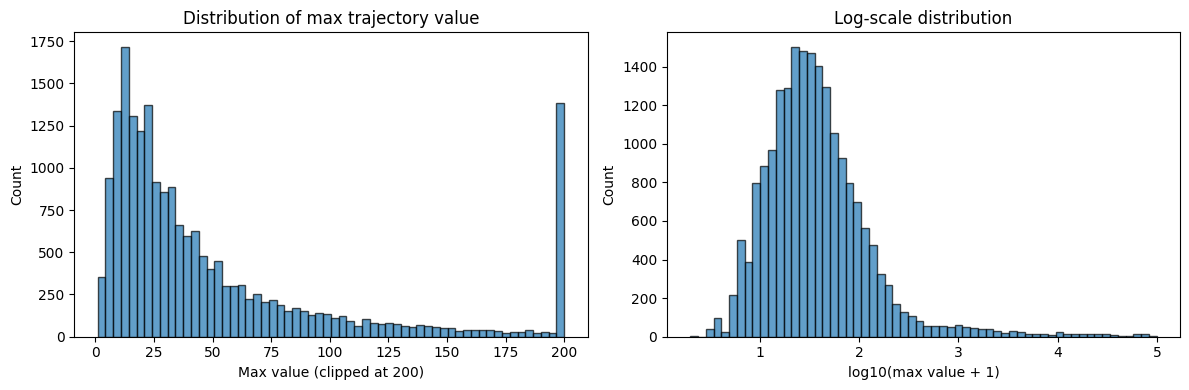

In [10]:
max_vals = np.array([c[2]["max_val"] for c in train_cls])

print("=== Trajectory value range ===")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  {p:5.1f}th percentile: {np.percentile(max_vals, p):.1f}")
print(f"  max:  {max_vals.max():.1f}")
print(f"  Items with max > 100 : {(max_vals > 100).sum()}")
print(f"  Items with max > 1000: {(max_vals > 1000).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(max_vals, 0, 200), bins=60, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Max value (clipped at 200)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of max trajectory value")

axes[1].hist(np.log10(max_vals + 1), bins=60, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("log10(max value + 1)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-scale distribution")

plt.tight_layout()
plt.show()

## CRN topology statistics

Species per item:
  2 species:   9684  (48.4%)
  3 species:  10316  (51.6%)

Active species per item:
  0 active :    895  (4.5%)
  1 active :   6170  (30.9%)
  2 active :   9239  (46.2%)
  3 active :   3696  (18.5%)

Reactions per item:
  3 reactions:    966  (4.8%)
  4 reactions:   4178  (20.9%)
  5 reactions:   5273  (26.4%)
  6 reactions:   4845  (24.2%)
  7 reactions:   4046  (20.2%)
  8 reactions:    667  (3.3%)
  9 reactions:     25  (0.1%)


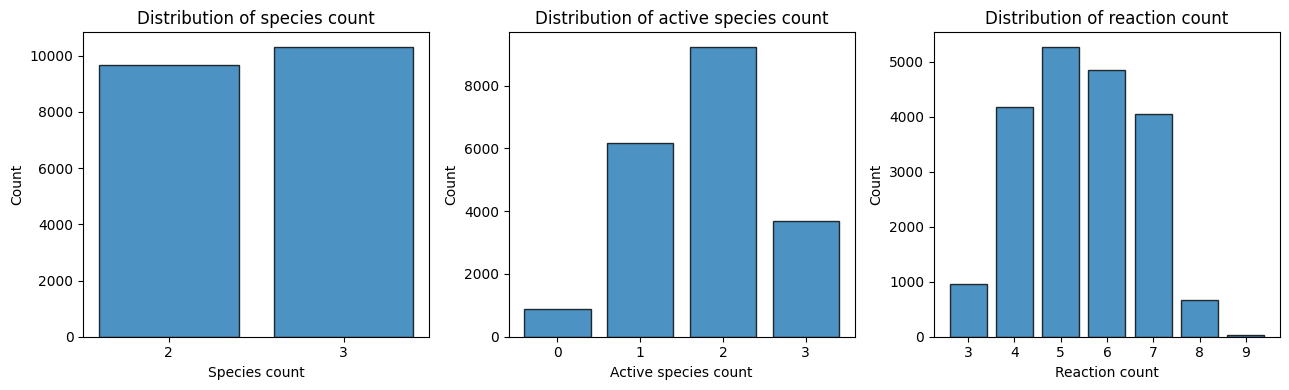

In [11]:
n_species_dist = Counter(c[2]["n_species"] for c in train_cls)
n_active_dist = Counter(c[2]["n_active_species"] for c in train_cls)

# Reactions come from the CRN tensor repr stoichiometry shape

n_reactions_list = []
for i in range(len(train_dataset)):
    item = train_dataset[i]
    # stoichiometry: (max_n_reactions, max_n_species) — count non-zero rows
    stoich = item.crn_repr.stoichiometry  # shape (R, S)
    n_active_rxns = int((stoich.abs().sum(dim=1) > 0).sum())
    n_reactions_list.append(n_active_rxns)
n_reactions_dist = Counter(n_reactions_list)

print("Species per item:")
for k, v in sorted(n_species_dist.items()):
    print(f"  {k} species: {v:6d}  ({100 * v / len(train_cls):.1f}%)")

print("\nActive species per item:")
for k, v in sorted(n_active_dist.items()):
    print(f"  {k} active : {v:6d}  ({100 * v / len(train_cls):.1f}%)")

print("\nReactions per item:")
for k, v in sorted(n_reactions_dist.items()):
    print(f"  {k} reactions: {v:6d}  ({100 * v / len(train_cls):.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, dist, title in zip(
    axes,
    [n_species_dist, n_active_dist, n_reactions_dist],
    ["Species count", "Active species count", "Reaction count"],
):
    ks = sorted(dist)
    ax.bar(ks, [dist[k] for k in ks], edgecolor="black", alpha=0.8)
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {title.lower()}")
    ax.set_xticks(ks)

plt.tight_layout()
plt.show()

## Species-level regime breakdown

In [12]:
all_species_labels = []
for sp_labels, _, _ in train_cls:
    all_species_labels.extend(sp_labels)

species_counts = Counter(all_species_labels)
total_species = sum(species_counts.values())

print("=== Species-level regime distribution ===")
for label, cnt in sorted(species_counts.items(), key=lambda x: -x[1]):
    print(f"  {label:<20s}: {cnt:6d}  ({100 * cnt / total_species:.1f}%)")

=== Species-level regime distribution ===
  near_zero           :  14580  (29.0%)
  decay_to_nonzero    :  10179  (20.2%)
  transient_peak      :   7996  (15.9%)
  growth              :   7613  (15.1%)
  decay_to_zero       :   5483  (10.9%)
  slow_dynamics       :   2159  (4.3%)
  steady_state        :   2132  (4.2%)
  blowup              :    168  (0.3%)
  oscillatory         :      6  (0.0%)


## Temporal statistics

For deterministic data, temporal mean and variance profiles give a direct view of how the ODE evolves on average across the dataset.

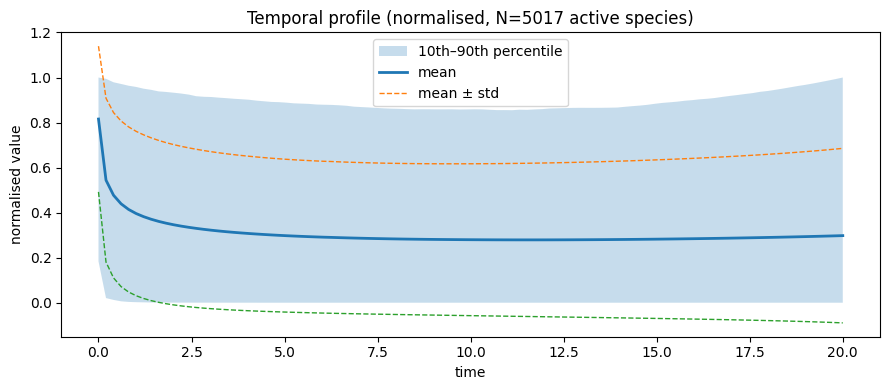

In [13]:
# Aggregate normalised trajectories across the dataset
# Normalise each trajectory by its own max so very different scales can be overlaid.
N_SAMPLE = min(2000, len(train_dataset))
rng = np.random.default_rng(1)
sample_idx = rng.choice(len(train_dataset), size=N_SAMPLE, replace=False)

T = train_dataset[0].trajectories.shape[1]
normed_trajs = []  # (N_SAMPLE, T)  — one species per entry (all species concatenated)

for idx in sample_idx:
    item = train_dataset[int(idx)]
    traj = item.trajectories[0].numpy()  # (T, S)
    for s in range(traj.shape[1]):
        sp = traj[:, s]
        scale = np.abs(sp).max() + 1e-6
        if scale > 0.5:  # skip near-zero species
            normed_trajs.append(sp / scale)

normed_trajs = np.array(normed_trajs)  # (N, T)
t_axis = train_dataset[0].times.numpy()

mean_profile = normed_trajs.mean(axis=0)
std_profile = normed_trajs.std(axis=0)
p10 = np.percentile(normed_trajs, 10, axis=0)
p90 = np.percentile(normed_trajs, 90, axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(t_axis, p10, p90, alpha=0.25, label="10th–90th percentile")
ax.plot(t_axis, mean_profile, lw=2, label="mean")
ax.plot(t_axis, mean_profile + std_profile, lw=1, ls="--", label="mean ± std")
ax.plot(t_axis, mean_profile - std_profile, lw=1, ls="--")
ax.set_xlabel("time")
ax.set_ylabel("normalised value")
ax.set_title(f"Temporal profile (normalised, N={len(normed_trajs)} active species)")
ax.legend()
plt.tight_layout()
plt.show()

## Steady-state check

For the deterministic setting the surrogate should learn to reproduce the ODE trajectory.
This cell checks how many trajectories are close to a true steady state by the end of the simulation
(|x(T) - x(T/2)| / x(T/2) < threshold).

In [14]:
THRESHOLD = 0.05  # 5% relative change in second half → near steady state

n_at_ss = 0
for i in range(len(train_dataset)):
    traj = train_dataset[i].trajectories[0].numpy()  # (T, S)
    T, S = traj.shape
    half = T // 2
    mid_val = np.abs(traj[half, :]).mean() + 1e-6
    end_val = np.abs(traj[-1, :]).mean()
    rel_diff = abs(end_val - mid_val) / mid_val
    if rel_diff < THRESHOLD:
        n_at_ss += 1

print(f"Items near steady state at t_end (rel. change < {THRESHOLD:.0%}):")
print(
    f"  {n_at_ss} / {len(train_dataset)}  ({100 * n_at_ss / len(train_dataset):.1f}%)"
)
print()
print("Note: for surrogate training we want diverse dynamics, not just steady states.")

Items near steady state at t_end (rel. change < 5%):
  6214 / 20000  (31.1%)

Note: for surrogate training we want diverse dynamics, not just steady states.
